# Gaussian Mixture Models

### Clustering that admits it is uncertain

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a mixture model differs from k-means, what expectation-maximisation does, what the covariance types buy you, and what BIC does and does not tell you about the number of components |
| **You should already know** | [k-Means](../01-k-means/) |
| **Dataset** | UCI Dry Bean, plus stretched blobs that broke k-means |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [05-06 Anomaly detection](../06-anomaly-detection/) |

---

## 1. The idea

[k-means](../01-k-means/) had two limits. Every cluster is a sphere, and every
point belongs to exactly one of them.

A Gaussian mixture relaxes both. It assumes the data was generated by $k$ normal
distributions, each with its **own centre and its own shape**, and it reports for
every point the **probability** it came from each one.

$$p(x) = \sum_{i=1}^{k} \pi_i \, \mathcal{N}(x \mid \mu_i, \Sigma_i)$$

Three things per component: how common it is ($\pi_i$), where it sits ($\mu_i$),
and what shape it has ($\Sigma_i$). That covariance matrix is the whole upgrade:
it lets a cluster be a stretched, tilted ellipse instead of a ball.

k-means is the special case where every $\Sigma_i$ is the identity and every point
is assigned with probability 1. **k-means is a hard, spherical mixture model.**

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Expectation-maximisation

The fitting problem is circular. If you knew which component produced each point,
you could compute the components. If you knew the components, you could work out
which produced each point. You know neither.

EM breaks the circle by guessing and alternating:

**E-step.** Given the current components, compute the probability each point came
from each one. These are the *responsibilities*.

**M-step.** Given those probabilities, recompute each component's centre, shape
and weight, as a weighted average over all points, weighted by responsibility.

Each round provably increases the likelihood, so it converges. It converges to a
*local* optimum, which is why `n_init` matters exactly as it did for k-means.

Notice the shape of the algorithm is identical to Lloyd's: assign, update,
repeat. The only change is that assignment is soft.

## 3. The shapes k-means could not see

k-means  adjusted Rand : 0.589
GMM      adjusted Rand : 0.796

points assigned with less than 80% confidence: 17.3%


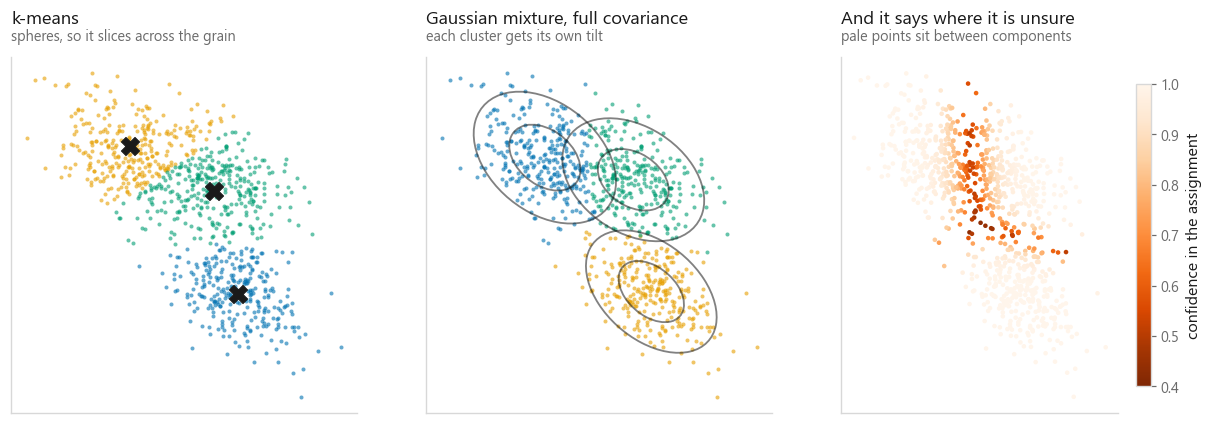

In [2]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse

rng = np.random.default_rng(SEED)
blobs = make_blobs(n_samples=900, centers=3, cluster_std=1.0, random_state=SEED)[0]
stretched = blobs @ np.array([[0.7, -0.7], [0.15, 0.9]])


def draw_ellipses(ax, model):
    for i in range(model.n_components):
        covariance = model.covariances_[i]
        values, vectors = np.linalg.eigh(covariance)
        angle = np.degrees(np.arctan2(vectors[1, -1], vectors[0, -1]))
        width, height = 2 * np.sqrt(values[::-1])
        for scale in (1, 2):
            ax.add_patch(Ellipse(model.means_[i], scale * width, scale * height, angle=angle,
                                 facecolor="none", edgecolor=style.INK, lw=1.2, alpha=0.55))


fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2), sharex=True, sharey=True)

km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(stretched)
for c in range(3):
    sel = km.labels_ == c
    axes[0].scatter(stretched[sel, 0], stretched[sel, 1], s=7, alpha=0.6,
                    c=style.PALETTE[c], linewidths=0)
axes[0].scatter(*km.cluster_centers_.T, s=140, marker="X", c=style.INK, zorder=5)
style.title(axes[0], "k-means", "spheres, so it slices across the grain")

gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=10,
                      random_state=SEED).fit(stretched)
labels = gmm.predict(stretched)
for c in range(3):
    sel = labels == c
    axes[1].scatter(stretched[sel, 0], stretched[sel, 1], s=7, alpha=0.6,
                    c=style.PALETTE[c], linewidths=0)
draw_ellipses(axes[1], gmm)
style.title(axes[1], "Gaussian mixture, full covariance", "each cluster gets its own tilt")

confidence = gmm.predict_proba(stretched).max(axis=1)
scatter = axes[2].scatter(stretched[:, 0], stretched[:, 1], s=9, c=confidence,
                          cmap="Oranges_r", vmin=0.4, vmax=1.0, linewidths=0)
fig.colorbar(scatter, ax=axes[2], shrink=0.85, label="confidence in the assignment")
style.title(axes[2], "And it says where it is unsure", "pale points sit between components")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
style.save(fig, FIG / "fig-01-shapes.png")

from sklearn.metrics import adjusted_rand_score
true_labels = make_blobs(n_samples=900, centers=3, cluster_std=1.0, random_state=SEED)[1]
print(f"k-means  adjusted Rand : {adjusted_rand_score(true_labels, km.labels_):.3f}")
print(f"GMM      adjusted Rand : {adjusted_rand_score(true_labels, labels):.3f}")
print(f"\npoints assigned with less than 80% confidence: {(confidence < 0.8).mean():.1%}")

The third panel is the thing k-means genuinely cannot do. Points near a boundary
come out pale, meaning the model is telling you it does not know. k-means assigns
every point with equal, unearned certainty.

## 4. The covariance types

`covariance_type` is the dial that decides how much shape each cluster may have,
and it trades flexibility against the number of parameters to estimate.

     type  parameters   ARI
spherical          11 0.578
     diag          14 0.645
     tied          11 0.796
     full          17 0.796

best ARI 0.796, reached by: tied, full
cheapest way to reach it : tied, 11 parameters
dearest way to reach it  : full, 17 parameters


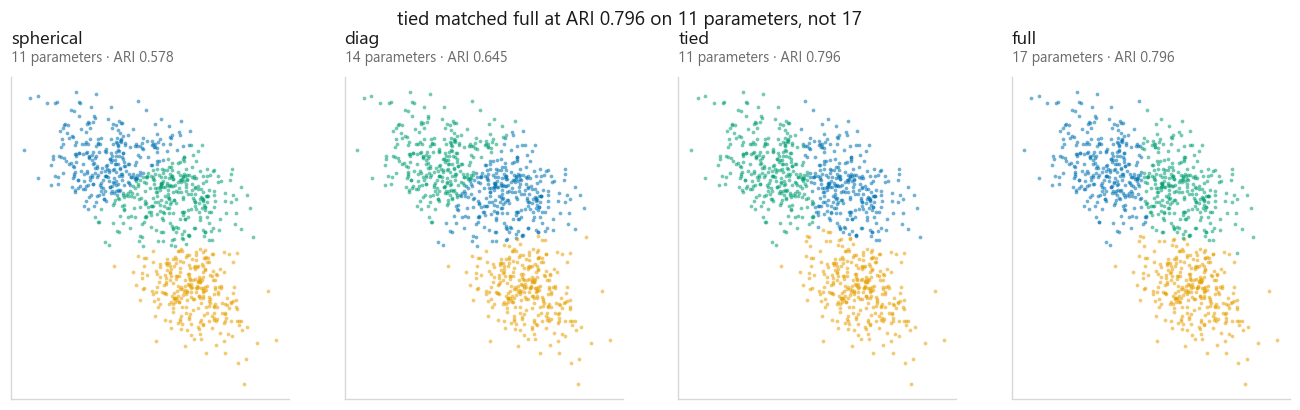

In [3]:
types = ["spherical", "diag", "tied", "full"]
fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.8), sharex=True, sharey=True)
shape_cost = []

for ax, kind in zip(axes, types):
    model = GaussianMixture(n_components=3, covariance_type=kind, n_init=10,
                            random_state=SEED).fit(stretched)
    assignment = model.predict(stretched)
    ari = adjusted_rand_score(true_labels, assignment)
    shape_cost.append({"type": kind, "parameters": model._n_parameters(), "ARI": ari})
    for c in range(3):
        sel = assignment == c
        ax.scatter(stretched[sel, 0], stretched[sel, 1], s=6, alpha=0.55,
                   c=style.PALETTE[c], linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, kind, f"{model._n_parameters()} parameters · ARI {ari:.3f}")

shape_cost = pd.DataFrame(shape_cost)
winners = shape_cost[np.isclose(shape_cost.ARI, shape_cost.ARI.max())]
cheapest = winners.loc[winners.parameters.idxmin()]
dearest = winners.loc[winners.parameters.idxmax()]

fig.suptitle(f"{cheapest['type']} matched {dearest['type']} at ARI {cheapest.ARI:.3f} "
             f"on {int(cheapest.parameters)} parameters, not {int(dearest.parameters)}",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-covariance-types.png")

print(shape_cost.round(3).to_string(index=False))
print(f"\nbest ARI {shape_cost.ARI.max():.3f}, reached by: "
      f"{', '.join(winners['type'])}")
print(f"cheapest way to reach it : {cheapest['type']}, {int(cheapest.parameters)} parameters")
print(f"dearest way to reach it  : {dearest['type']}, {int(dearest.parameters)} parameters")

**spherical** is k-means with soft assignment, one variance per cluster.
**diag** allows axis-aligned ellipses. **tied** gives every cluster the same
shape, sharing one covariance matrix. **full** lets every cluster tilt freely,
and costs the most parameters.

The ranking is not the one the extra freedom would predict. `tied` scored ARI
0.796 on 11 parameters, and `full` scored the same 0.796 on 17. `tied` also
beat `diag`, 0.796 against 0.645, while costing fewer parameters than `diag`
needed. More freedom bought a lot over `spherical`, and after that it bought
nothing at all.

The reason is in how I built the data. `stretched` is three isotropic blobs put
through one linear map, so all three clusters come out with the **same**
covariance. That is precisely what `tied` assumes, so `tied` is the correctly
specified model here, and `full` is spending six extra parameters estimating
three matrices that were always going to agree. `diag` does worse than either
because the shared shape is tilted and `diag` is not allowed to tilt.

The rule survives in a more useful form: **the cheapest covariance type whose
assumption is true will match or beat every richer one.** Reach for `full` when
you do not know the shapes and have data to spare, and check whether something
cheaper gets to the same place first, because with few points per cluster a
full covariance matrix is how a mixture model overfits.

## 5. Choosing k with a criterion instead of an elbow, and what went wrong

[k-means](../01-k-means/) had no principled way to choose k: the elbow was a
judgement call and the silhouette disagreed with the truth. A mixture model is a
proper probability model, so it can be scored by likelihood, and **BIC** penalises
that likelihood by the number of parameters used to earn it.

$$\text{BIC} = -2\log L + p \log n$$

Lower is better. The promise of the penalty is that BIC *can* turn around,
which inertia never does: every extra component costs $p \log n$, and at some
$k$ that charge should outgrow the likelihood it buys. Whether the turn happens
inside the range you actually sweep is a separate question, and on this dataset
it is the interesting one.

              ARI                BIC             
covariance   diag   full        diag         full
k                                                
2           0.275  0.297  441945.255  -697488.185
3           0.400  0.379  384933.218  -780145.415
4           0.440  0.421  328997.422  -853217.080
5           0.575  0.519  284816.860  -910264.843
6           0.705  0.696  231386.361  -954128.138
7           0.639  0.682  206960.652  -996969.784
8           0.656  0.575  188841.732 -1016426.910
9           0.609  0.602  175358.468 -1036254.413
10          0.558  0.575  159968.451 -1048519.959
11          0.539  0.515  151809.069 -1056048.779
12          0.496  0.494  145129.989 -1074463.544

BIC falls at every step, both covariance types : True
lowest BIC in the swept range : k = 12, full (the last k tried, so not a minimum)
best agreement with the truth : k = 6, diag, ARI 0.705
true varieties                : 7

the last component added (full, k = 11 -> 12):
   extra parameters  :    

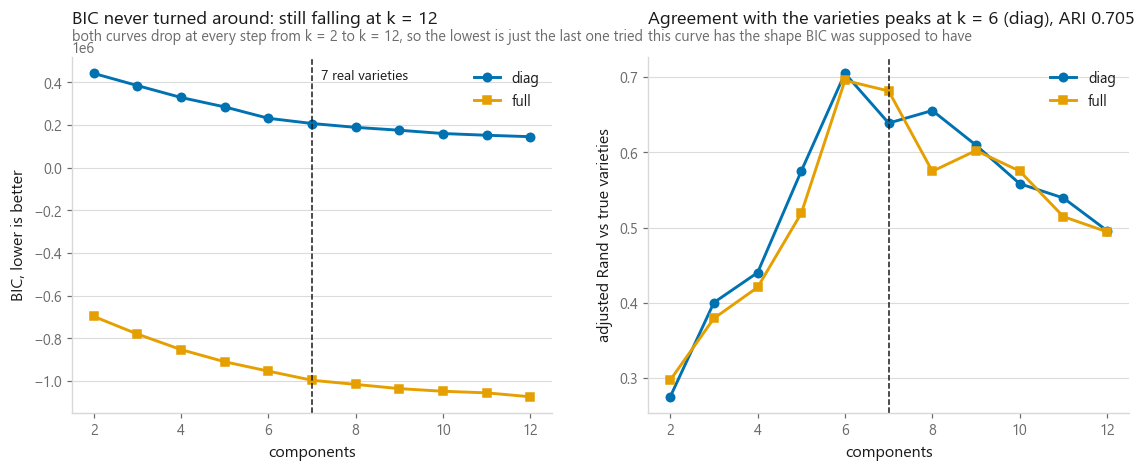

In [4]:
X_bean, y_bean = datasets.dry_bean()
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_bean)

records = []
for k in range(2, 13):
    for kind in ["diag", "full"]:
        model = GaussianMixture(n_components=k, covariance_type=kind, n_init=3,
                                random_state=SEED).fit(X_scaled)
        records.append({"k": k, "covariance": kind, "BIC": model.bic(X_scaled),
                        "parameters": model._n_parameters(),
                        "ARI": adjusted_rand_score(y_bean, model.predict(X_scaled))})
sweep = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
for i, kind in enumerate(["diag", "full"]):
    subset = sweep[sweep.covariance == kind]
    axes[0].plot(subset["k"], subset["BIC"], marker=style.MARKERS[i],
                 color=style.PALETTE[i], label=kind)
    axes[1].plot(subset["k"], subset["ARI"], marker=style.MARKERS[i],
                 color=style.PALETTE[i], label=kind)

lowest = sweep.loc[sweep.BIC.idxmin()]
k_min, k_max = int(sweep.k.min()), int(sweep.k.max())
still_falling = all(
    bool(sweep[sweep.covariance == c].sort_values("k").BIC.diff().dropna().lt(0).all())
    for c in ["diag", "full"]
)

axes[0].axvline(7, color=style.INK, ls="--", lw=1)
axes[0].annotate("7 real varieties", xy=(7, sweep.BIC.max()), xytext=(6, -4),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xlabel("components"); axes[0].set_ylabel("BIC, lower is better")
axes[0].legend()
style.title(
    axes[0],
    f"BIC never turned around: still falling at k = {k_max}" if still_falling
    else f"BIC prefers k = {int(lowest.k)} ({lowest.covariance})",
    f"both curves drop at every step from k = {k_min} to k = {k_max}, so the lowest "
    f"is just the last one tried" if still_falling
    else "the parameter charge finally outgrew the likelihood",
)

peak = sweep.loc[sweep.ARI.idxmax()]
axes[1].axvline(7, color=style.INK, ls="--", lw=1)
axes[1].set_xlabel("components"); axes[1].set_ylabel("adjusted Rand vs true varieties")
axes[1].legend()
style.title(axes[1],
            f"Agreement with the varieties peaks at k = {int(peak.k)} ({peak.covariance}), "
            f"ARI {peak.ARI:.3f}",
            "this curve has the shape BIC was supposed to have")

style.save(fig, FIG / "fig-03-choosing-k.png")

print(sweep.pivot_table(index="k", columns="covariance", values=["BIC", "ARI"]).round(3).to_string())
print(f"\nBIC falls at every step, both covariance types : {still_falling}")
print(f"lowest BIC in the swept range : k = {int(lowest.k)}, {lowest.covariance} "
      f"(the last k tried, so not a minimum)")
print(f"best agreement with the truth : k = {int(peak.k)}, {peak.covariance}, ARI {peak.ARI:.3f}")
print(f"true varieties                : 7")

full_curve = sweep[sweep.covariance == "full"].sort_values("k")
d_bic = float(full_curve.BIC.diff().iloc[-1])
d_params = float(full_curve.parameters.diff().iloc[-1])
charge = d_params * np.log(len(X_scaled))
print(f"\nthe last component added (full, k = {k_max - 1} -> {k_max}):")
print(f"   extra parameters  : {d_params:>12,.0f}")
print(f"   parameter charge  : {charge:>12,.0f}")
print(f"   likelihood credit : {charge - d_bic:>12,.0f}")
print(f"   net change in BIC : {d_bic:>12,.0f}   (negative means BIC wants more)")
print(f"   credit is {(charge - d_bic) / charge:.1f}x the charge")

kmeans_ari = adjusted_rand_score(y_bean, KMeans(7, n_init=10, random_state=SEED).fit_predict(X_scaled))
gmm7 = sweep[(sweep.k == 7)].sort_values("ARI").iloc[-1]
print(f"\nadjusted Rand at k=7: GMM {gmm7.ARI:.3f} ({gmm7.covariance}), k-means {kmeans_ari:.3f}")

**BIC never turned around.** Read the table before reading anything else: from
k = 2 to k = 12 the BIC falls at every single step, for both covariance types.
Diag goes 441,945 down to 145,130. Full goes -697,488 down to -1,074,464. There
is no minimum anywhere in the range I swept, and the lowest value sits at
k = 12 because k = 12 is where I stopped.

So "BIC prefers twelve components" would be a false reading of my own chart. It
is the same failure as the [k-means elbow](../01-k-means/) reporting the largest
k you tried. What I measured is that on this dataset, in this range, BIC has no
opinion about the number of varieties.

The arithmetic of the last step says why, and it is not close. Going from eleven
to twelve full-covariance components adds 153 parameters, which at n = 13,611
costs about 1,456 of BIC. The likelihood improved by about 19,871 in the same
units, which is 13.6 times the charge. The penalty is not weak; it is simply
outgunned, and nothing in the last few steps suggests the gap is closing.

That is the honest lesson, and it is more useful than a tidy minimum would have
been:

1. **BIC is not a defence against runaway k on its own.** The penalty grows like
   $p \log n$, which is linear in $k$. The likelihood also keeps growing. Which
   one wins is an empirical question about your data, and here the likelihood
   was winning comfortably at every k I tried.
2. **A minimum you did not observe is not a minimum.** If you want to claim BIC
   chose something, the curve has to visibly turn inside your range. Mine does
   not, so I cannot make the claim.
3. **BIC answers a density question, not your question.** Seven real varieties,
   each slightly non-Gaussian in shape, are described better by twelve Gaussians
   than by seven, and better still by more. BIC is happily buying components to
   patch shape mismatch, exactly as it should. Nothing here is misbehaving. BIC
   is answering "how many Gaussians describe this density well", which is a
   different question from "how many kinds of bean are there".

The right panel is the contrast. Agreement with the true varieties **does** have
a peak, at k = 6 with diag covariance, ARI 0.705, one component below the truth
and then falling away on both sides. The curve that knows the answer has the
shape BIC was supposed to have, and the curve that does not know the answer
slides forever.

So use BIC the way you use inertia: as a sanity check with a known bias, not as
a decision. If you need a number of clusters, sweep far enough that the curve
turns or admit that it did not, and then look at the clusters.

At the true k of 7 the mixture does beat k-means on agreement with the real
varieties, which is the comparison that was actually asked.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Clusters are elliptical or differently shaped; you want probabilities rather than hard labels; you want a defensible way to narrow down k |
| **Avoid it when** | Clusters are non-convex: crescents and rings are still out of reach, use [DBSCAN](../04-dbscan-and-hdbscan/); you have very few points per cluster |
| **Scaling needed** | Yes, for the same reason as k-means |
| **Main dials** | `n_components`, `covariance_type`, `n_init` (keep it above 1, EM finds local optima) |
| **Choosing k** | BIC or AIC. Both *can* turn around where inertia cannot, but check that yours actually did. Mine fell at every k from 2 to 12 |
| **Bonus use** | `score_samples` gives a density, so a fitted mixture doubles as an [anomaly detector](../06-anomaly-detection/) |

## What to remember

1. A mixture model gives every cluster its own shape and every point a probability.
2. k-means is the hard, spherical special case.
3. EM alternates soft assignment and weighted re-estimation, and converges to a
   local optimum.
4. `covariance_type` trades shape freedom against parameters to estimate, and the
   cheapest type whose assumption is true wins. On my stretched blobs `tied` was
   that type: it matched `full` at ARI 0.796 on 11 parameters instead of 17.
5. BIC *can* turn around where inertia never does, and on this dataset it did
   not. It fell at every step from k = 2 to k = 12, so the lowest value is only
   the last one I tried. Do not report an unobserved minimum as a choice.
6. Adjusted Rand did peak, at k = 6, one below the truth. The metric that knows
   the answer has the shape BIC was supposed to have.
7. Pale points in the confidence plot are the model admitting uncertainty, which
   k-means never does.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-06 Anomaly detection](../06-anomaly-detection/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GaussianMixture` `#GMM` `#Clustering` `#UnsupervisedLearning`
`#ExpectationMaximization` `#Python` `#ScikitLearn` `#MLTutorial` `#BIC`